In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("pinterest_sentiment.csv")
df = df.dropna(subset=['clean_review'])

X = df['clean_review'].astype(str)
y = df['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [7]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

In [8]:
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

X_train_use = embed(X_train.tolist()).numpy()
X_test_use = embed(X_test.tolist()).numpy()

In [9]:
X_train_combined = np.hstack((X_train_tfidf, X_train_use))
X_test_combined = np.hstack((X_test_tfidf, X_test_use))

In [13]:
def run_classifiers(train_features, test_features, train_labels, test_labels, title, include_nb=True):
    print(f"--- Evaluasi: {title} ---")

    models = {
        "Linear SVC": LinearSVC(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=100)
    }

    if include_nb:
        models["Naive Bayes"] = MultinomialNB()

    results = {}
    for name, model in models.items():
        model.fit(train_features, train_labels)
        predictions = model.predict(test_features)
        acc = accuracy_score(test_labels, predictions)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")

    return results

In [14]:
tfidf_results = run_classifiers(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF Only", include_nb=True)
print("\n")

use_results = run_classifiers(X_train_use, X_test_use, y_train, y_test, "USE Only", include_nb=False)
print("\n")

combined_results = run_classifiers(X_train_combined, X_test_combined, y_train, y_test, "Combined TF-IDF + USE", include_nb=False)

--- Evaluasi: TF-IDF Only ---
Linear SVC Accuracy: 0.8673
Logistic Regression Accuracy: 0.8418
Random Forest Accuracy: 0.8265
Naive Bayes Accuracy: 0.7474


--- Evaluasi: USE Only ---
Linear SVC Accuracy: 0.8469
Logistic Regression Accuracy: 0.8469
Random Forest Accuracy: 0.8087


--- Evaluasi: Combined TF-IDF + USE ---
Linear SVC Accuracy: 0.8724
Logistic Regression Accuracy: 0.8724
Random Forest Accuracy: 0.8138


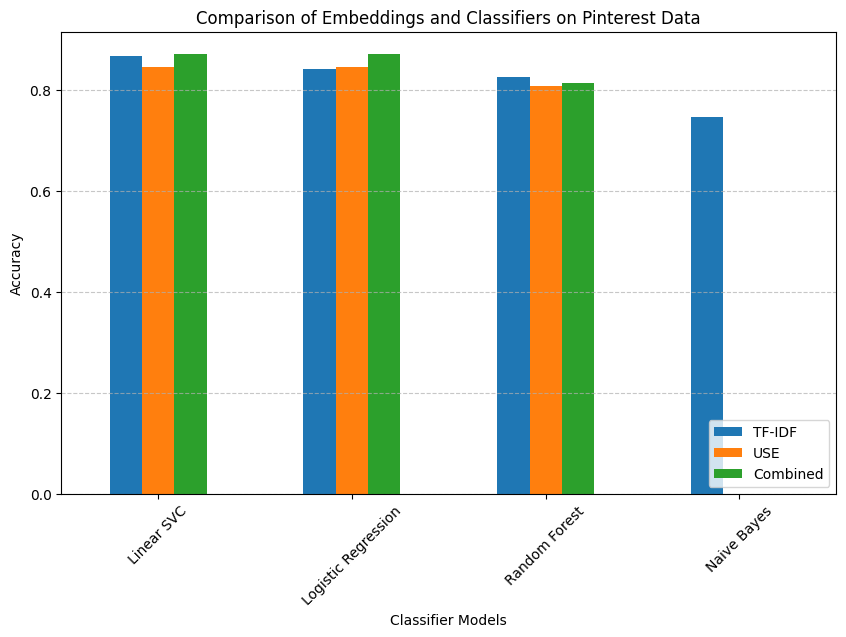

In [16]:
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "TF-IDF": tfidf_results,
    "USE": use_results,
    "Combined": combined_results
})

comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Embeddings and Classifiers on Pinterest Data')
plt.ylabel('Accuracy')
plt.xlabel('Classifier Models')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()